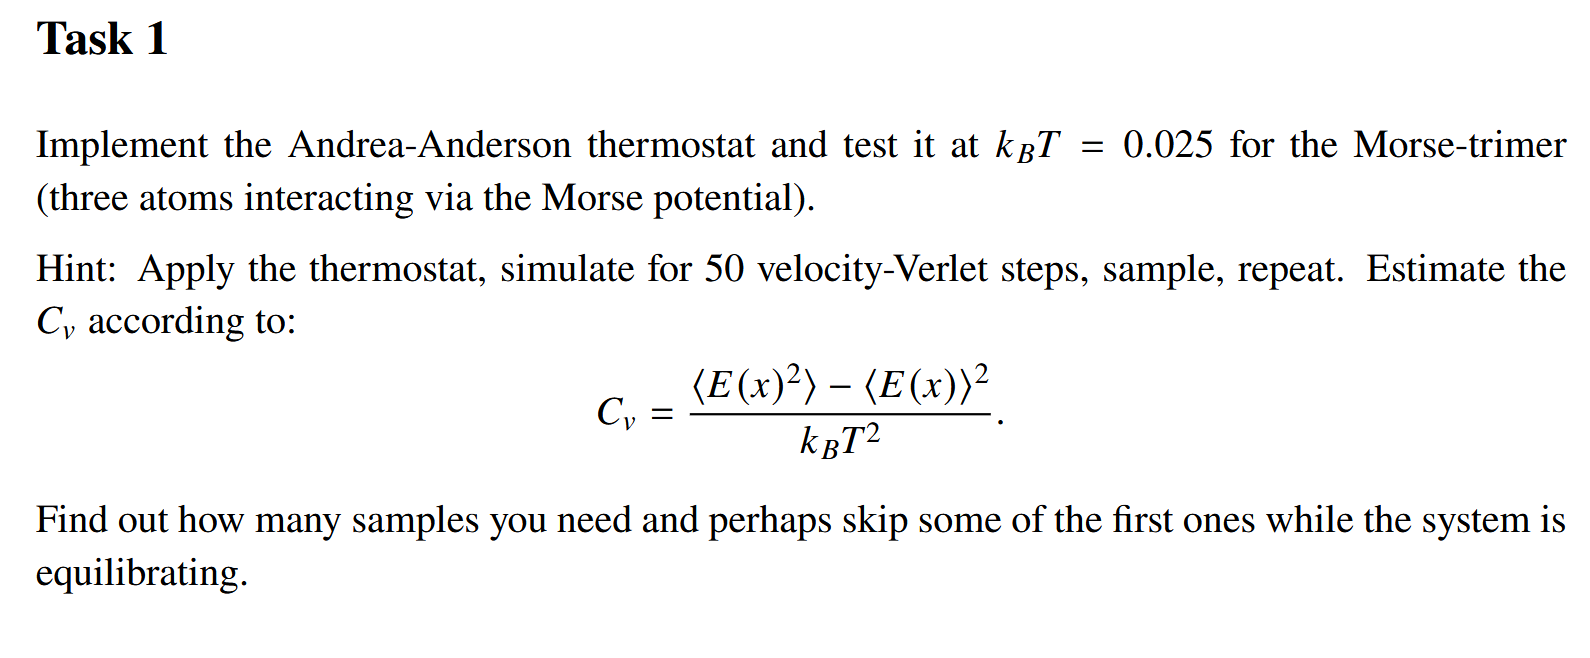

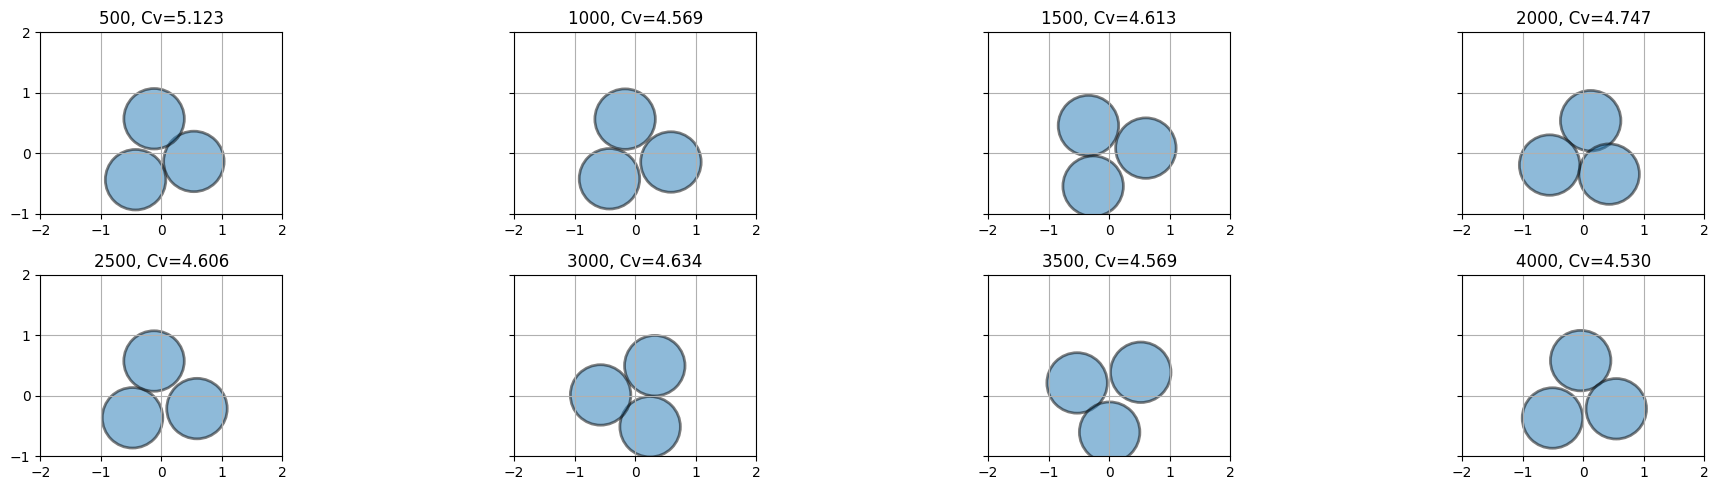

In [ ]:
import numpy as np
from week04 import *

class AtomicCluster(AtomicCluster):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.v = np.zeros(self.pos.shape)

    @property
    def K(self):
        return 0.5 * np.sum(self.v**2) # assume m=1

    def get_velocity(self):
        return self.v.copy()
    
    def set_velocity(self, v):
        self.v = v

    def draw_title(self, ax):
        ek = self.K
        ep = self.potential_energy
        etot = ek+ep
        ax.set_title(f'Ek={ek:7.2f}, Ep={ep:7.2f}, E={etot:7.2f}')

def thermostat(cluster, kT):
    scale = np.sqrt(kT) # Assume m=1
    v_old = cluster.get_velocity()
    v_new = np.random.normal(0, scale, size=v_old.shape)
    
    cluster.set_velocity(v_new)

def velocity_verlet(cluster, N=100, dt=0.01):
    a_t = cluster.forces # assume m=1
    r = cluster.get_positions()
    v = cluster.get_velocity()

    for _ in range(N):
        r += v*dt + 0.5*a_t*dt**2
        cluster.set_positions(r)

        a_dt = cluster.forces # assume m=1

        v += 0.5* (a_t + a_dt) * dt

        a_t = a_dt.copy()

    cluster.set_velocity(v)

    e = cluster.potential_energy + cluster.K
    return cluster.get_positions, e

morse = Morse()
pos = [[0,0], [-1.5, 1.5], [1.5, 0]]
static = [False, False, False]
cluster = AtomicCluster(morse, pos=pos, static=static)

fig, axes = plt.subplots(2, 4, figsize=(16, 6), sharey=True)
axes = axes.flatten()

kT = 0.025
xs = []
es = []
for ax in axes:
    for _ in range(500):
        thermostat(cluster, kT)

        x, e = velocity_verlet(cluster, 50)

        xs.append(x)
        es.append(e)

    # 1. Calculate the center of mass position
    com_pos = np.mean(cluster.get_positions(), axis=0)
    # 2. Shift the entire cluster back to the origin (0, 0)
    cluster.set_positions(cluster.get_positions() - com_pos)

    cluster.draw(ax)
    nice_plot(ax)

    Cv = np.var(es[400:]) / (kT**2)
    
    ax.set_title(f'{len(es)}, Cv={Cv:.3f}')

plt.tight_layout()

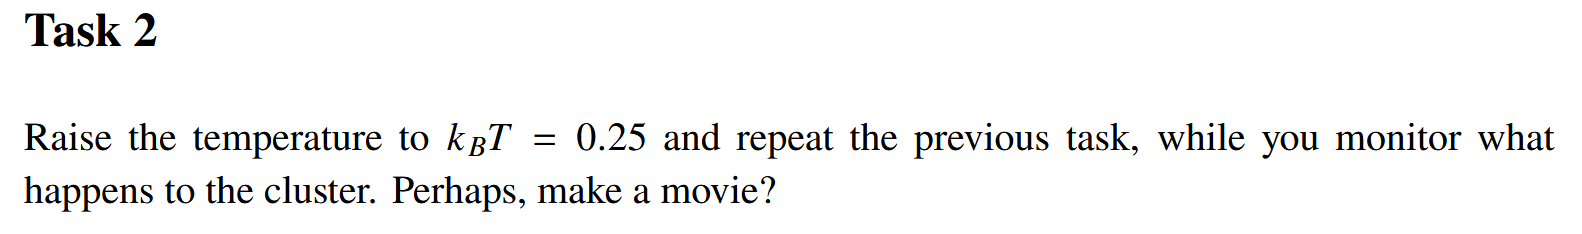

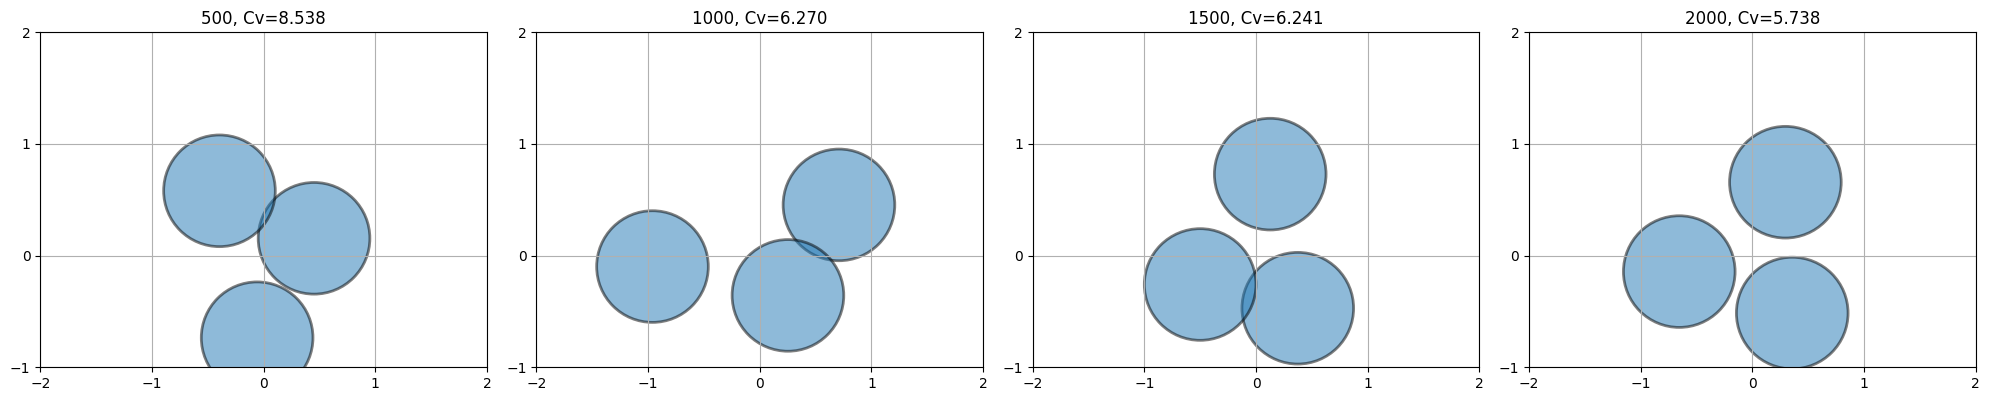

In [41]:
morse = Morse()
pos = [[0,0], [-1.5, 1.5], [1.5, 0]]
static = [False, False, False]
cluster = AtomicCluster(morse, pos=pos, static=static)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))


kT = 0.25
xs = []
es = []
for ax in axes:
    for _ in range(500):
        thermostat(cluster, kT)

        x, e = velocity_verlet(cluster, 50)

        xs.append(x)
        es.append(e)

    # 1. Calculate the center of mass position
    com_pos = np.mean(cluster.get_positions(), axis=0)
    # 2. Shift the entire cluster back to the origin (0, 0)
    cluster.set_positions(cluster.get_positions() - com_pos)

    cluster.draw(ax)
    nice_plot(ax)

    Cv = np.var(es[400:]) / (kT**2)
    
    ax.set_title(f'{len(es)}, Cv={Cv:.3f}')

plt.tight_layout()

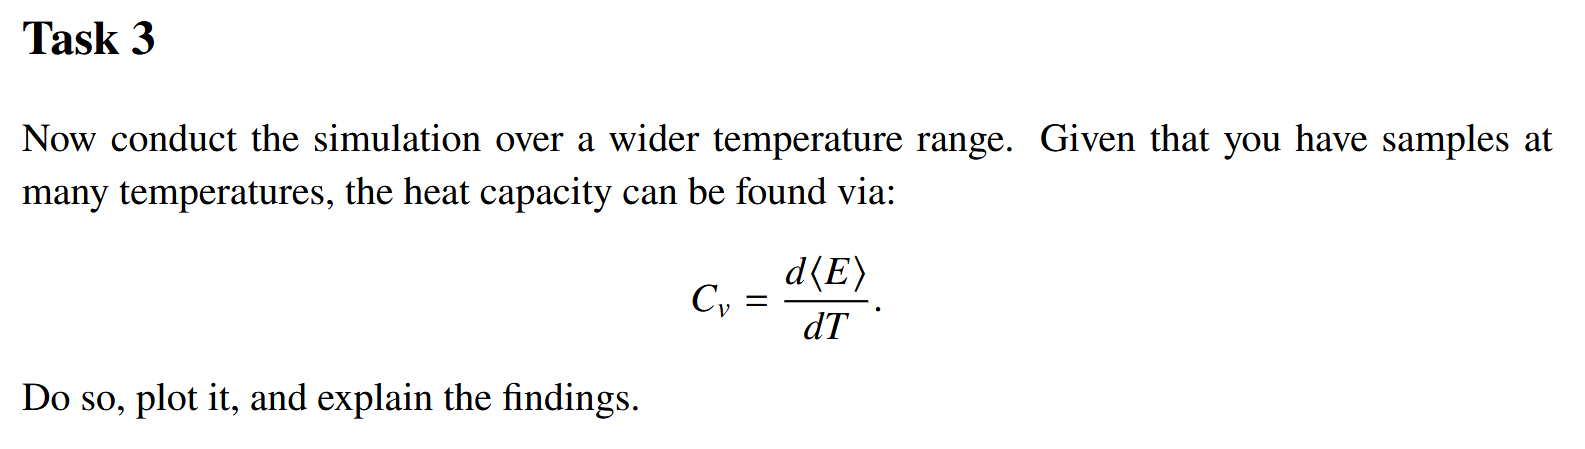

Starting temperature sweep...
Finished kT=0.100 | <E>=-4.01
Finished kT=0.167 | <E>=-3.67
Finished kT=0.233 | <E>=-3.30
Finished kT=0.300 | <E>=-2.84
Finished kT=0.367 | <E>=-2.38
Finished kT=0.433 | <E>=0.69
Finished kT=0.500 | <E>=0.95
Finished kT=0.567 | <E>=1.68
Finished kT=0.633 | <E>=1.88
Finished kT=0.700 | <E>=2.05


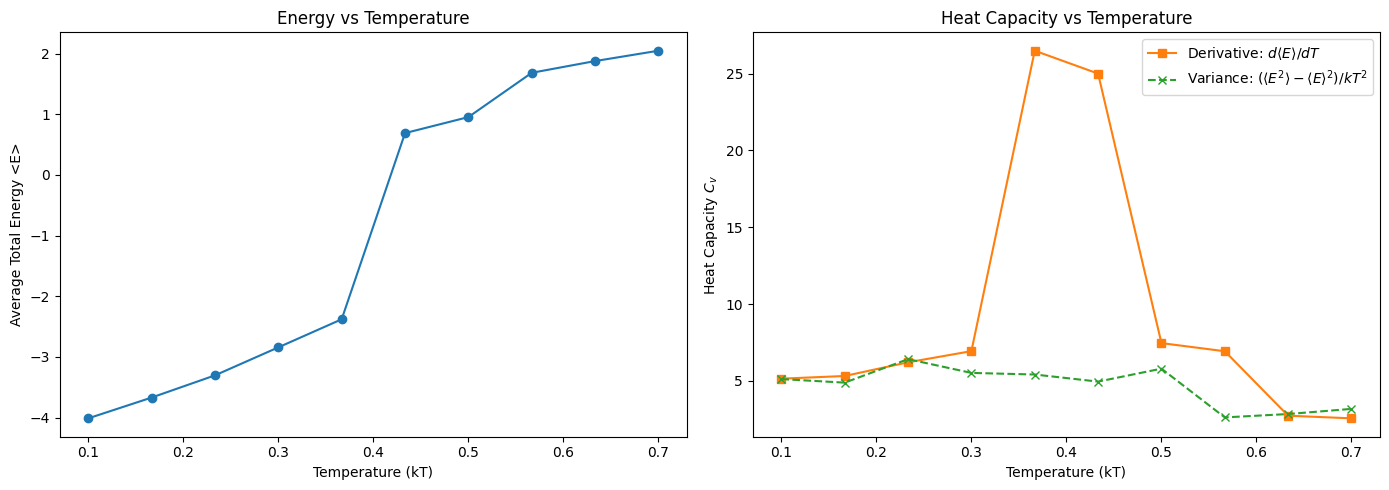

In [ ]:
# Define a range of temperatures
kTs = np.linspace(0.1, 0.7, 10) 
avg_energies = []
cv_variance = [] 

print("Starting temperature sweep...")

for kT in kTs:
    cluster = AtomicCluster(Morse(), pos=[[0,0], [-1.5, 1.5], [1.5, 0]], static=[False, False, False])
    
    es = []
    
    for _ in range(1000):
        thermostat(cluster, kT)
        _, e = velocity_verlet(cluster, N=50, dt=0.01)
        es.append(e)
        
    # Calculate <E> skipping the 500-step burn-in
    eq_energies = es[500:]
    avg_E = np.mean(eq_energies)
    avg_energies.append(avg_E)
    
    cv_variance.append(np.var(eq_energies) / kT**2)
    
    print(f"Finished kT={kT:.3f} | <E>={avg_E:.2f}")

# Calculate Cv = d<E>/dT using numpys gradient function
Cv_derivative = np.gradient(avg_energies, kTs)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot <E> vs T
ax1.plot(kTs, avg_energies, 'o-', color='C0')
ax1.set_xlabel('Temperature (kT)')
ax1.set_ylabel('Average Total Energy <E>')
ax1.set_title('Energy vs Temperature')

# Plot both Cv calculations
ax2.plot(kTs, Cv_derivative, 's-', color='C1', label=r'Derivative: $d\langle E\rangle/dT$')
ax2.plot(kTs, cv_variance, 'x--', color='C2', label=r'Variance: $(\langle E^2\rangle - \langle E\rangle^2)/kT^2$')
ax2.set_xlabel('Temperature (kT)')
ax2.set_ylabel('Heat Capacity $C_v$')
ax2.set_title('Heat Capacity vs Temperature')
ax2.legend()

plt.tight_layout()
plt.show()